# 2D Gravity with PhysicsSchool

Simulating particles interacting via a Poisson field equation: $\nabla^2 \phi = \rho$

This gives Newtonian gravity in 2D, where the force scales as $F \propto 1/r$.

In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from physchool.worlds.field_sampler import FieldSampler

%matplotlib inline
plt.rcParams.update({'font.size': 13})

## Measure force vs separation

For a general operator $(-\nabla^2)^\alpha \phi = \rho$ in 2D, the Green's function is $G(r) \propto r^{2\alpha - 2}$ (for $\alpha \neq 1$; logarithmic at $\alpha = 1$). The force is:

$$F = -\nabla\phi \propto r^{2\alpha - 3}$$

| $\alpha$ | Operator | Force scaling |
|---|---|---|
| 0.5 | $(-\nabla^2)^{1/2}$ | $F \propto 1/r^2$ |
| 0.75 | $(-\nabla^2)^{3/4}$ | $F \propto 1/r^{3/2}$ |
| 1.0 | $\nabla^2$ (Laplacian) | $F \propto 1/r$ |
| 1.25 | $(-\nabla^2)^{5/4}$ | $F \propto 1/r^{1/2}$ |
| 1.5 | $(-\nabla^2)^{3/2}$ | $F \approx$ constant |

Lower $\alpha$ means steeper force (more "short-range"), higher $\alpha$ means flatter (more "long-range"). Let's measure this numerically.

**Note**: Lower $\alpha$ requires higher grid resolution since the Green's function is more singular.

In [2]:
def measure_force(alpha, separation, grid_size=128, domain_size=30.0):
    """Measure force between two unit-mass particles at given separation."""
    if alpha == 1.0:
        ops = [{'type': 'laplacian', 'params': {'strength': 1.0}}]
    else:
        ops = [{'type': 'fractional_laplacian', 'params': {'strength': 1.0, 'alpha': alpha}}]
    
    center = domain_size / 2
    positions = np.array([[center - separation/2, center],
                          [center + separation/2, center]])
    masses = np.ones(2)
    
    s = FieldSampler(
        particle_inertia=masses, particle_source=masses, particle_force=masses,
        initial_positions=positions, initial_velocities=np.zeros((2, 2)),
        spatial_dimensions=2, temporal_order=0,
        grid_size=(grid_size, grid_size), domain_size=domain_size,
        operators=ops, n_particles=2, force_law='gradient', dt=0.01,
        source_coupling=masses, force_coupling=1.0, periodic_boundaries=False,
    )
    forces = s.step()
    return float(jnp.sqrt(jnp.sum(forces[0]**2)))

In [3]:
alphas = [0.5, 0.75, 1.0, 1.25, 1.5]
separations = np.linspace(1.5, 8.0, 12)

results = {}
for alpha in alphas:
    forces = [measure_force(alpha, sep) for sep in separations]
    results[alpha] = np.array(forces)
    print(f"alpha={alpha:.2f} done")

alpha=0.50 done
alpha=0.75 done
alpha=1.00 done
alpha=1.25 done
alpha=1.50 done


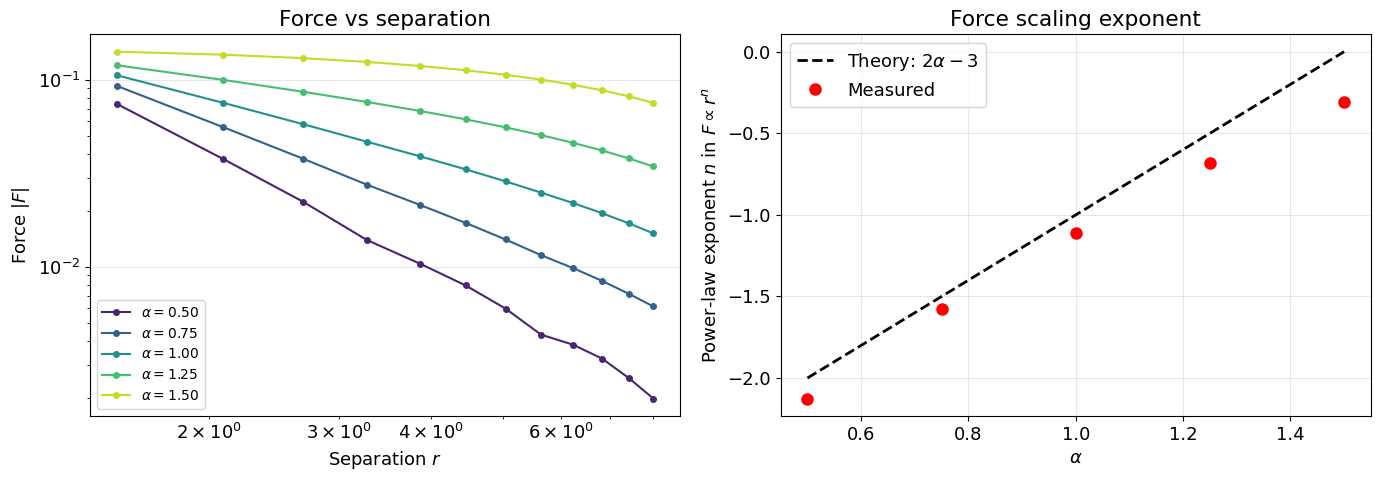

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Force vs separation (log-log)
ax = axes[0]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(alphas)))
for alpha, color in zip(alphas, colors):
    ax.loglog(separations, results[alpha], 'o-', color=color, label=rf'$\alpha={alpha:.2f}$', ms=4)

ax.set_xlabel('Separation $r$')
ax.set_ylabel('Force $|F|$')
ax.set_title('Force vs separation')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: Measured power law vs theory
ax = axes[1]
measured_slopes = []
expected_slopes = []
for alpha in alphas:
    mask = (separations > 2.0) & (separations < 6.0)
    log_r = np.log(separations[mask])
    log_f = np.log(results[alpha][mask])
    slope = np.polyfit(log_r, log_f, 1)[0]
    measured_slopes.append(slope)
    expected_slopes.append(2*alpha - 3)  # F ~ r^(2a-3)

ax.plot(alphas, expected_slopes, 'k--', lw=2, label=r'Theory: $2\alpha - 3$')
ax.plot(alphas, measured_slopes, 'ro', ms=8, label='Measured')
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('Power-law exponent $n$ in $F \propto r^n$')
ax.set_title('Force scaling exponent')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Orbits

Let's watch two particles orbit each other under standard Newtonian gravity ($\alpha=1$, $F \propto 1/r$) and compare with a fractional Laplacian ($\alpha=1.5$, $F \approx$ const — very long-range).

In [5]:
def run_orbit(alpha, n_steps=2000, dt=0.005):
    """Run a two-body orbit and return trajectory arrays."""
    if alpha == 1.0:
        ops = [{'type': 'laplacian', 'params': {'strength': 1.0}}]
    else:
        ops = [{'type': 'fractional_laplacian', 'params': {'strength': 1.0, 'alpha': alpha}}]
    
    domain = 50.0
    center = domain / 2
    separation = 4.0
    positions = np.array([[center - separation/2, center],
                          [center + separation/2, center]])
    masses = np.ones(2)
    
    # Estimate circular velocity from measured force
    F = measure_force(alpha, separation)
    v_circ = np.sqrt(F * separation / 2)  # F = mv^2/r_orbit, r_orbit = sep/2
    velocities = np.array([[0, v_circ], [0, -v_circ]])
    
    s = FieldSampler(
        particle_inertia=masses, particle_source=masses, particle_force=masses,
        initial_positions=positions, initial_velocities=velocities,
        spatial_dimensions=2, temporal_order=0,
        grid_size=(128, 128), domain_size=domain,
        operators=ops, n_particles=2, force_law='gradient', dt=dt,
        source_coupling=masses, force_coupling=1.0, periodic_boundaries=False,
    )
    
    traj = [s.positions.copy()]
    for _ in range(n_steps):
        s.step()
        traj.append(s.positions.copy())
    
    return np.array(traj)

traj_newton = run_orbit(1.0)
traj_frac = run_orbit(1.5)
print("Done")

Done


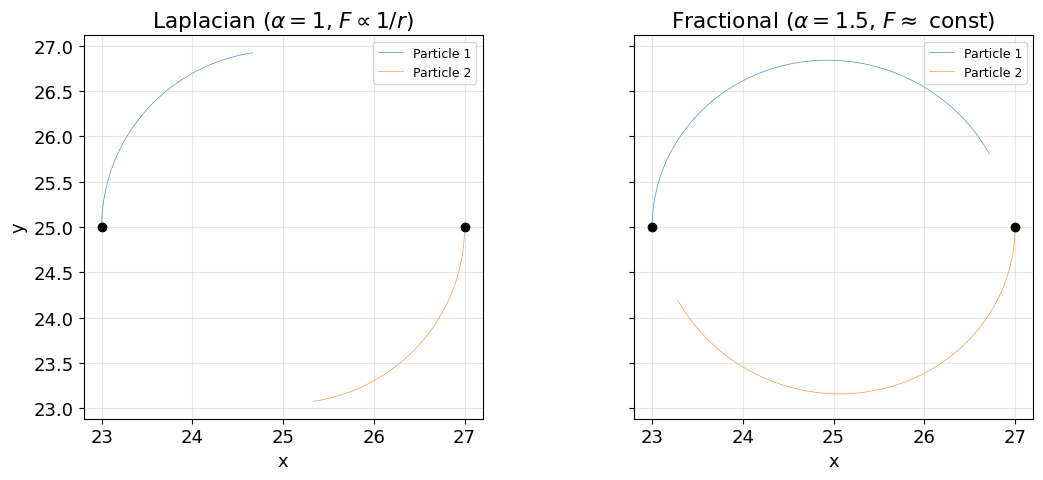

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, traj, label in [(axes[0], traj_newton, r'Laplacian ($\alpha=1$, $F \propto 1/r$)'),
                          (axes[1], traj_frac, r'Fractional ($\alpha=1.5$, $F \approx$ const)')]:
    ax.plot(traj[:, 0, 0], traj[:, 0, 1], '-', lw=0.5, alpha=0.8, label='Particle 1')
    ax.plot(traj[:, 1, 0], traj[:, 1, 1], '-', lw=0.5, alpha=0.8, label='Particle 2')
    ax.plot(*traj[0, 0], 'ko', ms=6)
    ax.plot(*traj[0, 1], 'ko', ms=6)
    ax.set_title(label)
    ax.set_xlabel('x')
    ax.set_aspect('equal')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('y')
plt.tight_layout()
plt.show()

## The field itself

Let's visualize what the gravitational potential $\phi$ looks like for a few different $\alpha$ values with a small cluster of particles.

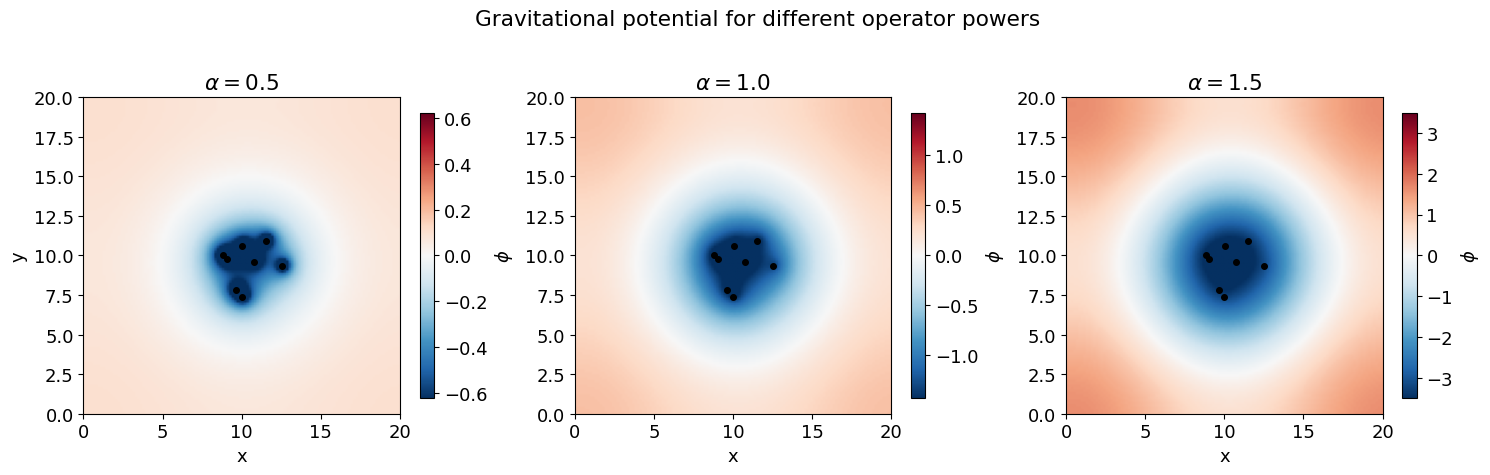

In [7]:
np.random.seed(7)
n_particles = 8
domain = 20.0
center = domain / 2
positions = np.random.randn(n_particles, 2) * 1.5 + center
masses = np.ones(n_particles)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
plot_alphas = [0.5, 1.0, 1.5]

for ax, alpha in zip(axes, plot_alphas):
    if alpha == 1.0:
        ops = [{'type': 'laplacian', 'params': {'strength': 1.0}}]
    else:
        ops = [{'type': 'fractional_laplacian', 'params': {'strength': 1.0, 'alpha': alpha}}]
    
    s = FieldSampler(
        particle_inertia=masses, particle_source=masses, particle_force=masses,
        initial_positions=positions, initial_velocities=np.zeros((n_particles, 2)),
        spatial_dimensions=2, temporal_order=0,
        grid_size=(128, 128), domain_size=domain,
        operators=ops, n_particles=n_particles, force_law='gradient', dt=0.01,
        source_coupling=masses, force_coupling=1.0,
    )
    s.step()
    
    extent = [0, domain, 0, domain]
    im = ax.imshow(s.field.T, origin='lower', extent=extent, cmap='RdBu_r',
                   vmin=-np.percentile(np.abs(s.field), 98),
                   vmax=np.percentile(np.abs(s.field), 98))
    ax.plot(positions[:, 0], positions[:, 1], 'k.', ms=8)
    ax.set_title(rf'$\alpha = {alpha}$')
    ax.set_xlabel('x')
    plt.colorbar(im, ax=ax, shrink=0.8, label=r'$\phi$')

axes[0].set_ylabel('y')
plt.suptitle('Gravitational potential for different operator powers', y=1.02)
plt.tight_layout()
plt.show()